# Análise Descritiva da Base

**Contexto:** a base é uma simulação de Monte Carlo com 1.200 cenários (futuros financeiros possíveis) para uma mesma empresa concessionária de infraestrutura, ao longo de 12 anos (Ano 1 = 2027 ... Ano 12 = 2038, ano de encerramento da concessão). Todos os valores são projeções — não há dados históricos reais.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

# Carregar o DataFrame
df = pd.read_excel('Dados_Formatados_CTI.xlsx')

# Limpar e converter a coluna 'Valor' ANTES de filtrar os dados
if df['Valor'].dtype == 'object':
    df['Valor'] = (
        df['Valor']
        .astype(str)
        .str.replace('.', '', regex=False) # Remover o ponto de milhar
        .str.replace(',', '.', regex=False) # Trocar a vírgula decimal por ponto
    )
    df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

# Definir a conta alvo para a análise
conta_alvo = 'FLU Geracao de Caixa'
df_conta = df[df['Conta'] == conta_alvo].copy()

# Calcular as medidas de posição e dispersão agrupadas por Ano
estatisticas = df_conta.groupby('Ano')['Valor'].agg(
    Média='mean',
    Mediana='median',
    Variância='var',
    Desvio_Padrão='std'
).round(2)
estatisticas = estatisticas.sort_index(key=lambda idx: idx.astype(str).str.extract(r'(\d+)', expand=False).astype(int))
print(f"Tabela de Estatísticas Descritivas: {conta_alvo}")

display(estatisticas)

Tabela de Estatísticas Descritivas: FLU Geracao de Caixa


,Média,Mediana,Variância,Desvio_Padrão
Ano,,,,
Ano 1,3.432745e+08,4.158085e+08,3.334990e+16,1.826196e+08
Ano 2,-2.403491e+08,-1.942555e+08,1.374926e+16,1.172573e+08
Ano 3,7.131920e+08,7.343328e+08,3.854667e+15,6.208597e+07
Ano 4,-6.243099e+08,-6.327643e+08,4.055939e+15,6.368626e+07
Ano 5,-7.098024e+08,-8.030491e+08,5.054615e+16,2.248247e+08
Ano 6,-2.179193e+07,-3.032143e+07,1.772634e+15,4.210266e+07
Ano 7,1.466313e+08,1.610914e+08,6.416319e+15,8.010193e+07
Ano 8,8.803332e+08,9.233143e+08,2.786857e+16,1.669388e+08
Ano 9,4.509495e+08,4.937548e+08,2.991630e+16,1.729633e+08


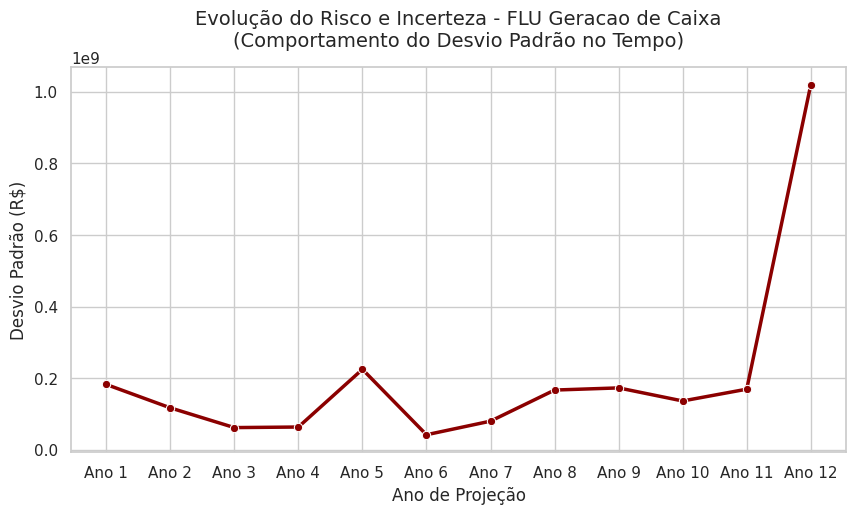

In [ ]:
estatisticas = estatisticas.sort_index(key=lambda idx: idx.astype(str).str.extract(r'(\d+)', expand=False).astype(int))
plt.figure(figsize=(10, 5))

# Plotar a evolução do Desvio Padrão
sns.lineplot(data=estatisticas, x=estatisticas.index, y='Desvio_Padrão',
             marker='o', color='darkred', linewidth=2.5)

plt.title(f'Evolução do Risco e Incerteza - {conta_alvo}\n(Comportamento do Desvio Padrão no Tempo)', fontsize=14, pad=15)
plt.xlabel('Ano de Projeção', fontsize=12)
plt.ylabel('Desvio Padrão (R$)', fontsize=12)
plt.xticks(estatisticas.index) # Garantir que todos os anos apareçam no eixo X

plt.show()

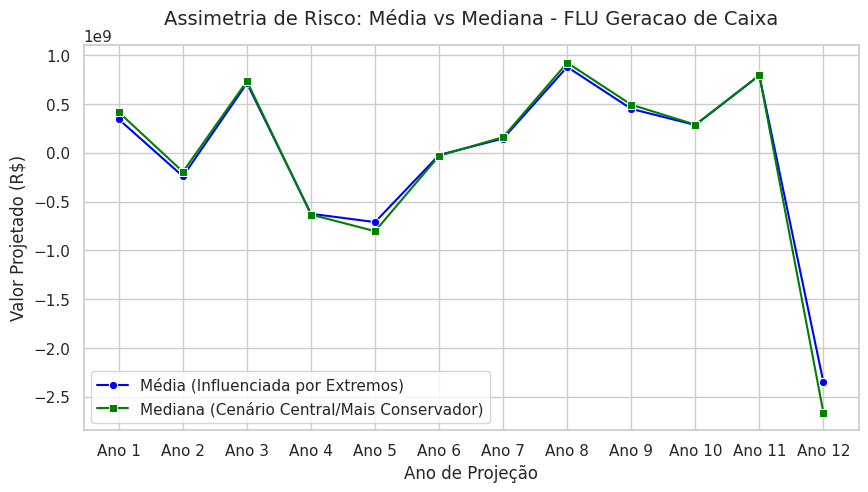

In [ ]:
plt.figure(figsize=(10, 5))

# Plot de Média e Mediana
sns.lineplot(data=estatisticas, x=estatisticas.index, y='Média',
             marker='o', label='Média (Influenciada por Extremos)', color='blue')
sns.lineplot(data=estatisticas, x=estatisticas.index, y='Mediana',
             marker='s', label='Mediana (Cenário Central/Mais Conservador)', color='green')

plt.title(f'Assimetria de Risco: Média vs Mediana - {conta_alvo}', fontsize=14, pad=15)
plt.xlabel('Ano de Projeção', fontsize=12)
plt.ylabel('Valor Projetado (R$)', fontsize=12)
plt.xticks(estatisticas.index)
plt.legend()

plt.show()

/tmp/ipykernel_867/780566609.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_conta, x='Ano', y='Valor',


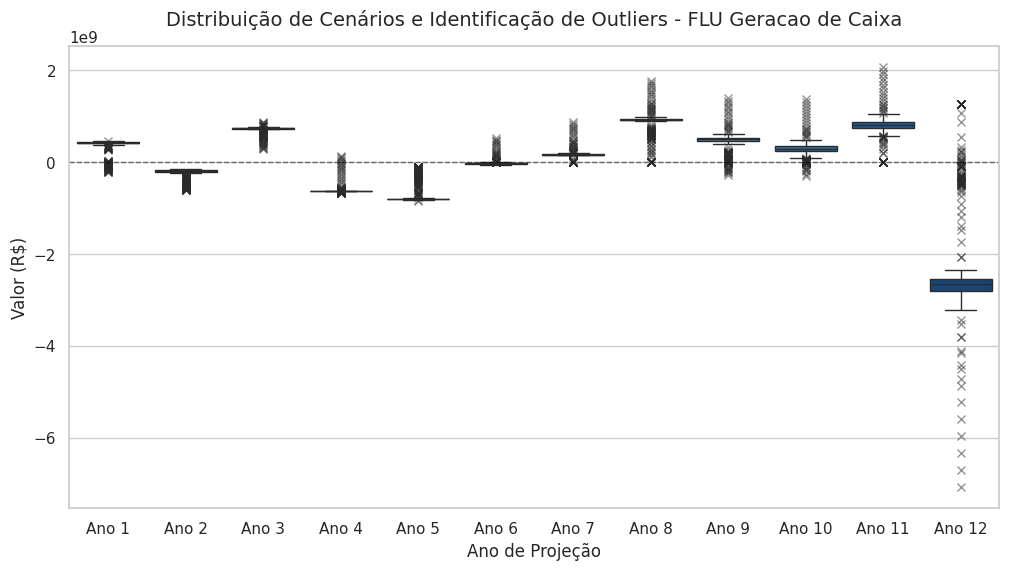

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot agrupado por Ano. O Seaborn faz a separação automaticamente.
sns.boxplot(data=df_conta, x='Ano', y='Valor',
            palette='Blues',
            flierprops={'marker': 'x', 'color': 'red', 'alpha': 0.5}) # Destaca outliers

plt.title(f'Distribuição de Cenários e Identificação de Outliers - {conta_alvo}', fontsize=14, pad=15)
plt.xlabel('Ano de Projeção', fontsize=12)
plt.ylabel('Valor (R$)', fontsize=12)

# Adicionar linha no zero para facilitar a visualização de prejuízos/caixa negativo
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.show()

Foram encontrados 1200 cenários para o Ano 1.


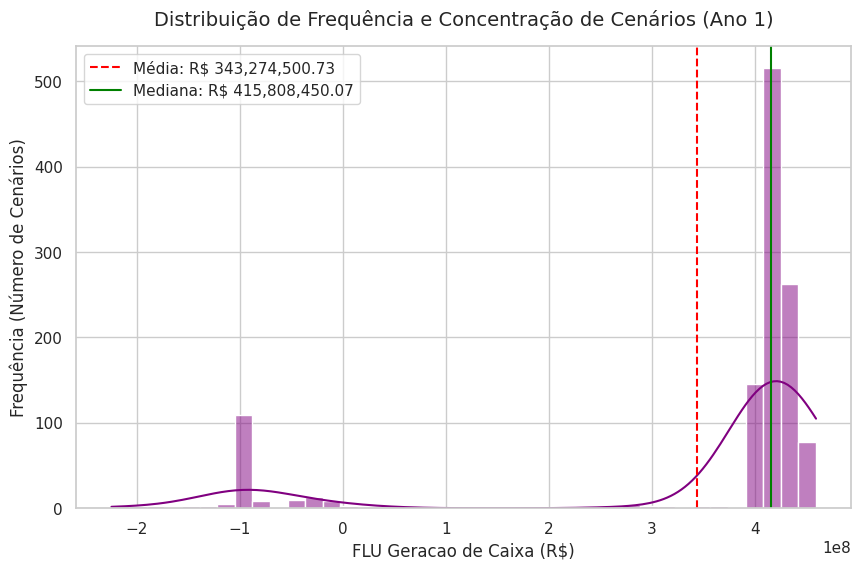

In [ ]:
# Definir o ano como está escrito na coluna do seu Excel
ano_analise = 'Ano 1'
df_ano_especifico = df_conta[df_conta['Ano'] == ano_analise]

# Trava de segurança para saber se o filtro funcionou
print(f"Foram encontrados {len(df_ano_especifico)} cenários para o {ano_analise}.")

plt.figure(figsize=(10, 6))

# Criar Histograma com a Curva de Densidade (KDE)
sns.histplot(data=df_ano_especifico, x='Valor', bins=40, kde=True, color='purple')

# Adicionar linhas verticais para a Média e Mediana
media_ano = df_ano_especifico['Valor'].mean()
mediana_ano = df_ano_especifico['Valor'].median()

plt.axvline(media_ano, color='red', linestyle='--', label=f'Média: R$ {media_ano:,.2f}')
plt.axvline(mediana_ano, color='green', linestyle='-', label=f'Mediana: R$ {mediana_ano:,.2f}')

plt.title(f'Distribuição de Frequência e Concentração de Cenários ({ano_analise})', fontsize=14, pad=15)
plt.xlabel(f'{conta_alvo} (R$)', fontsize=12)
plt.ylabel('Frequência (Número de Cenários)', fontsize=12)
plt.legend()

plt.show()

In [ ]:
import pandas as pd
from IPython.display import display, HTML

def print_centro(texto):
    display(HTML(f"<h4 style='text-align: center;'>{texto}</h4>"))

conta_ativo = 'BAL Total do Ativo'
df_ativo = df[df['Conta'] == conta_ativo].copy()

percentis = df_ativo.groupby('Ano')['Valor'].quantile([0.30, 0.50, 0.75]).unstack().round(2)
percentis.columns = ['P30 (Pessimista)', 'P50 (Mediana/Central)', 'P75 (Otimista)']

percentis = percentis.sort_index(key=lambda x: x.str.extract(r'(\d+)', expand=False).astype(int))

print()

print_centro(f"Evolução dos Percentis: {conta_ativo}")

# Configurar estilo para centralizar a tabela e o texto dentro dela
estilo_centralizado = [
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto')]}, # Centralizar a tabela na tela
    {'selector': 'th', 'props': [('text-align', 'center')]}, # Centralizar o cabeçalho
    {'selector': 'td', 'props': [('text-align', 'center')]} # Centralizar os valores
]
display(percentis.style.format("R$ {:,.2f}").set_table_styles(estilo_centralizado))

ultimo_ano = 'Ano 11'
df_ultimo_ano = df_ativo[df_ativo['Ano'] == ultimo_ano]

# Piores Cenários (nsmallest pega os 10 menores valores)
top_10_piores = df_ultimo_ano.nsmallest(10, 'Valor')[['Cenario', 'Valor']]
top_10_piores.columns = ['Cenário', 'Valor do Ativo (Piores)']

# Melhores Cenários (nlargest pega os 10 maiores valores)
top_10_melhores = df_ultimo_ano.nlargest(10, 'Valor')[['Cenario', 'Valor']]
top_10_melhores.columns = ['Cenário', 'Valor do Ativo (Melhores)']

print()

print_centro(f"\nTop 10 Piores Cenários Projetados para o {ultimo_ano}")
display(top_10_piores.style.format({'Valor do Ativo (Piores)': "R$ {:,.2f}"}).hide(axis="index").set_table_styles(estilo_centralizado))

print()

print_centro(f"\nTop 10 Melhores Cenários Projetados para o {ultimo_ano}")
display(top_10_melhores.style.format({'Valor do Ativo (Melhores)': "R$ {:,.2f}"}).hide(axis="index").set_table_styles(estilo_centralizado))

,P30 (Pessimista),P50 (Mediana/Central),P75 (Otimista)
Ano,,,
Ano 1,"R$ 10,606,728,031.40","R$ 10,615,757,642.59","R$ 10,628,794,452.14"
Ano 2,"R$ 10,299,779,660.34","R$ 10,321,357,038.53","R$ 10,349,372,176.93"
Ano 3,"R$ 10,754,579,002.43","R$ 10,784,323,537.85","R$ 10,816,791,552.62"
Ano 4,"R$ 9,579,281,257.12","R$ 9,612,366,869.53","R$ 9,648,965,746.37"
Ano 5,"R$ 8,029,051,507.03","R$ 8,063,945,619.47","R$ 8,112,857,670.19"
Ano 6,"R$ 7,485,461,193.09","R$ 7,522,747,390.92","R$ 7,578,305,492.95"
Ano 7,"R$ 7,158,958,304.17","R$ 7,181,408,245.18","R$ 7,225,944,422.10"
Ano 8,"R$ 7,451,861,643.08","R$ 7,502,148,533.64","R$ 7,581,070,732.22"
Ano 9,"R$ 7,236,846,905.75","R$ 7,305,157,853.82","R$ 7,414,115,190.61"


Cenário,Valor do Ativo (Piores)
Total Cen_01069,"R$ 3,381,247,050.47"
Total Cen_01070,"R$ 3,393,813,948.17"
Total Cen_01071,"R$ 3,406,467,506.23"
Total Cen_01072,"R$ 3,423,149,036.99"
Total Cen_01073,"R$ 3,620,511,039.98"
Total Cen_01104,"R$ 3,631,079,827.83"
Total Cen_01103,"R$ 3,631,341,428.84"
Total Cen_01102,"R$ 3,631,602,771.68"
Total Cen_01101,"R$ 3,631,863,856.35"
Total Cen_01100,"R$ 3,632,124,682.86"


Cenário,Valor do Ativo (Melhores)
Total Cen_01128,"R$ 11,953,459,027.03"
Total Cen_01127,"R$ 11,577,864,607.57"
Total Cen_01126,"R$ 11,205,208,536.41"
Total Cen_01125,"R$ 10,835,468,436.19"
Total Cen_01124,"R$ 10,468,622,089.47"
Total Cen_01123,"R$ 10,104,647,437.66"
Total Cen_01122,"R$ 9,743,522,580.02"
Total Cen_01121,"R$ 9,385,225,772.62"
Total Cen_01120,"R$ 9,029,735,427.27"
Total Cen_01088,"R$ 8,865,849,883.96"
